In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

define plot types

In [17]:
import sys
sys.path.append("../utils")
from plotting_utils import format_top_3, plot_metric_grouped_by, plot_bio_vs_batch_correction_markers

In [5]:
# base_path = "/home/mila/m/myriam.lizotte/RF-MALI"
# mali_path = "/home/mila/m/myriam.lizotte/MALI"
# scratch_path = "/home/mila/m/myriam.lizotte/scratch/RF-MALI"

batch = 4

results_path = "/NOBACKUP/lizottem/fosta/results"
exp_name = "simulated_batches"
timestamp = "2026-05-04_01-29-41"
save_name = f"simulated_batches/{timestamp}/" #dataset}".format(dataset = dataset_name)
save_path = f"{results_path}/{save_name}"


create a new summary df based on aggregating the dfs in the n_comp subfolders

In [ ]:
# import os
# noises = [0.0, 0.5, 0.8, 1.0, 10.0]
# dropouts = [0.0, 0.1, 0.4, 0.8, 0.9]
# n_components_list = [2, 5, 10, 30]


# all_results_df = pd.DataFrame()
# for noise_std in noises:
#     for dropout_prob in dropouts:
#         for n_components in n_components_list:
#             save_path_subfolder = f"{save_path}/noise_{noise_std}_dropout_{dropout_prob}/{n_components}_components"

#             df = pd.read_csv(f"{save_path_subfolder}/simulated_batches_results.csv")

#             all_results_df = pd.concat([all_results_df, df], ignore_index=True)
        
# all_results_df    
# all_results_df.to_csv(f"{save_path}/simulated_batches_results.csv", index=False)
            

# Fake batches data

In [11]:
# load results
exp_name = "simulated_batches"
results_name = "simulated_batches"

# load results
results_df = pd.read_csv(f"{save_path}/{exp_name}_results.csv")


metric_type = results_df.loc[results_df["method"] == "Metric Type"]
metric_type = metric_type.drop(columns=['method', "noise", "dropout"]).drop_duplicates()
results_df = results_df.loc[results_df["method"] != "Metric Type"]

# # convert relevant columns to numeric
num_cols = results_df.columns.difference(['method', 'noise', 'dropout'])
results_df[num_cols] = results_df[num_cols].apply(pd.to_numeric, errors='coerce')

noise_dropout_cols = ['noise', 'dropout']
results_df[noise_dropout_cols] = results_df[noise_dropout_cols].apply(pd.to_numeric, errors='coerce')


# results_df = results_df.drop(0, axis = 0) # remove one run from debugging
results_df.drop_duplicates(subset=['n_components','method', 'noise', 'dropout'], keep='last', inplace=True)


# delete rows where n_components is NA
results_df = results_df.loc[~results_df["n_components"].isna()]
results_df = results_df.loc[~results_df["method"].isna()]


# remove n_components in the model column (it was just used to not overwrite adata, and it's already another column)
results_df["method"] = results_df["method"].str.replace(r'_\d+_components', '', regex=True)

In [12]:
results_df["method"].unique()

array(['Unintegrated', 'Harmony', 'ICML FoSTA t=2', 'ICML FoSTA t=auto',
       'KEMAlin', 'KEMArbf', 'LIGER', 'MALI', 'New FoSTA gap t=2',
       'New FoSTA gap t=auto', 'Pamona', 'Scanorama', 'scANVI', 'scVI'],
      dtype=object)

remove noise_std = 10 because that's really high and unrealistic (negative values in the counts?)

In [9]:
results_df = results_df.loc[results_df["noise_std"] != 10]
results_df = results_df.loc[results_df["noise_std"] != 2]

remove some of our methods

In [35]:
methods_to_remove= ["FoSTA_spectral", "FoSTA_UMAP", "RFMALI_spectral", "RFMALI_UMAP", "FoSTA_PHATE_t1", "RFMALI_PHATE_t1"]
# methods_to_remove += ["RFMALI_PHATE_t2"]
results_df = results_df[~results_df["method"].isin(methods_to_remove)]

# rename FOSTA PHATE t2 to FoSTA and RFMALI PHATE t2 to RFMALI
results_df["method"] = results_df["method"].replace({"FoSTA_PHATE_t2": "FoSTA"})
results_df["method"] = results_df["method"].replace({"RFMALI_PHATE_t2": "RFMALI"})

reorder the methods

In [36]:
methods_order = results_df["method"].unique().tolist()

for method in ["RFMALI", "FoSTA"]:
    if method in methods_order:
        methods_order.remove(method)
        methods_order.insert(0, method)

for method in ["Unintegrated"]:
    methods_order.remove(method)
    methods_order.append(method)

print(methods_order)

results_df["method"] = pd.Categorical(results_df["method"], ordered=True, categories = methods_order)

['FoSTA', 'RFMALI', 'MALI', 'Scanorama', 'LIGER', 'Harmony', 'scVI', 'scANVI', 'Pamona', 'KEMArbf', 'KEMAlin', 'Unintegrated']


In [8]:
results_df.loc[results_df["Total"].isna()] # there are no NAs. everything ran?

,n_components,noise_std,dropout_prob,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,...,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,time,memory


In [37]:
results_df

,n_components,noise_std,dropout_prob,method,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,...,BRAS,iLISI,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,time,memory
0,2,0.1,0.5,Unintegrated,0.514563,0.668227,0.496254,0.565559,0.305044,0.521759,...,0.553588,1.192093e-07,0.000000,0.568254,0.000000,0.224368,0.581629,0.438725,NaN,NaN
1,2,0.1,0.5,MALI,0.446926,0.400095,0.229670,0.381576,0.196164,0.400199,...,0.546465,9.307589e-01,0.595486,0.504220,0.999998,0.715385,0.432766,0.545814,17.528365,897.160085
2,2,0.1,0.5,RFMALI,0.488791,0.555134,0.269097,0.675486,0.594904,0.718859,...,0.562988,9.030611e-01,0.670889,0.678985,0.999972,0.763179,0.614610,0.674038,57.702654,846.203898
3,2,0.1,0.5,FoSTA,0.542330,0.561480,0.316976,0.631424,0.461603,0.684937,...,0.516020,8.833234e-01,0.643006,0.683331,0.999933,0.745123,0.599821,0.657942,88.858333,661.356409
4,2,0.1,0.5,Scanorama,0.555347,0.598067,0.384200,0.565461,0.277298,0.562284,...,0.393818,1.291412e-01,0.271895,0.769220,0.836507,0.480116,0.563211,0.529973,1.688066,226.365809
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1424,2,1.0,0.9,scVI,0.586299,0.590297,0.290945,0.544189,0.246741,0.521712,...,0.659697,9.523377e-01,0.980514,0.872775,0.999775,0.893020,0.540026,0.681224,173.695426,68.269789
1425,2,1.0,0.9,scANVI,0.619927,0.610050,0.312038,0.568097,0.288908,0.609154,...,0.749174,9.448020e-01,0.986122,0.843272,0.999940,0.904662,0.572596,0.705423,194.806901,68.193260
1426,2,1.0,0.9,Pamona,0.428493,0.213665,0.076182,0.167290,0.104715,0.486053,...,0.613323,1.586463e-01,0.024241,0.536231,0.995976,0.465684,0.346681,0.394282,334.154707,555.597120
1427,2,1.0,0.9,KEMArbf,0.328667,0.064477,0.004621,0.101282,0.037422,0.415735,...,0.653980,9.305255e-01,0.266893,0.460357,0.992098,0.660771,0.262096,0.421566,2.504500,7.973581


restrict to 2 components

In [10]:
results_df = results_df.loc[results_df["n_components"] == 2]

In [65]:
# cols_to_plot = ["Batch correction", "Bio conservation", "Total"]
# # 
# for col in cols_to_plot:
#     fig, ax = plt.subplots(figsize=(18,7), layout='constrained')


#     data = results_df.groupby(['n_components', 'method'])[col].mean()
#     # print(data)
   
#     sns.barplot(data=results_df, x = "n_components", y=col, hue="method", palette ="tab20")
#         # move legend outside   
    
    
#     plt.title(f"{col} by n_components")
#     plt.xticks(rotation=90)
#     plt.show()

# Bio vs batch

In [20]:
results_df.loc[results_df["method"]=="KEMAlin"]

,dropout,noise,seed,n_components,method,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,...,KBET,Graph connectivity,PCR comparison,Batch correction,Bio conservation,Total,cell_cycle_score,time,memory,folder
619,0.25,0.25,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
634,0.50,0.25,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
649,0.75,0.25,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
664,0.25,0.50,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
679,0.50,0.50,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
694,0.75,0.50,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
709,0.25,0.75,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
724,0.50,0.75,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN
739,0.75,0.75,4386721,2,KEMAlin,0.613752,0.439919,0.745645,0.755977,0.659791,...,0.37801,0.603846,0.941182,0.613672,0.701941,0.666633,0.301768,1.638407,5.061844,NaN


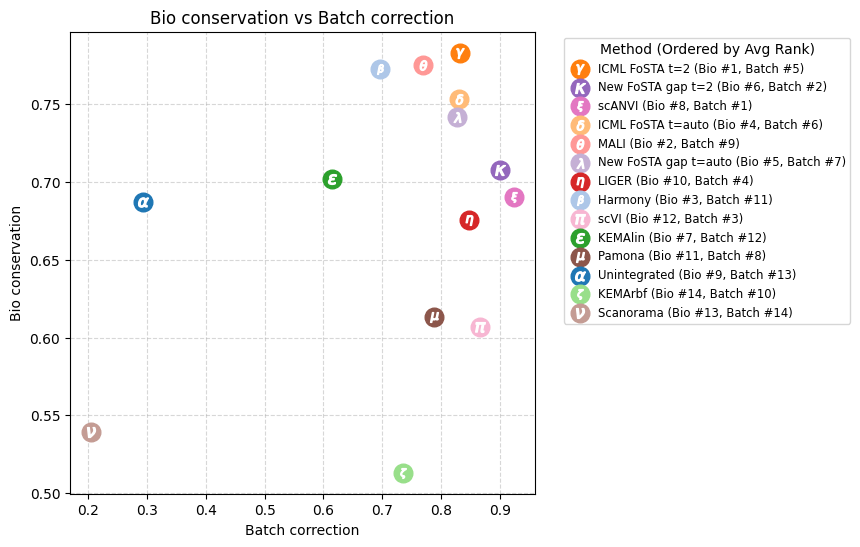

In [18]:
plot_bio_vs_batch_correction_markers(results_df)


# tables of bio and batch metrics

In [34]:
bio_metrics = []
batch_metrics = []
for metric in metric_type.columns:
    if (metric_type[metric] == "Bio conservation").values[0]:
        bio_metrics.append(metric)
        
    elif (metric_type[metric] == "Batch correction").values[0]:
        batch_metrics.append(metric)

In [279]:
bio_avg = results_df.groupby(['method'])[bio_metrics].mean()
bio_std = results_df.groupby(['method'])[bio_metrics].std()

/tmp/ipykernel_3722924/2675270494.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bio_avg = results_df.groupby(['method'])[bio_metrics].mean()
/tmp/ipykernel_3722924/2675270494.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bio_std = results_df.groupby(['method'])[bio_metrics].std()


In [288]:
batch_avg = results_df.groupby(['method'])[batch_metrics].mean()
batch_std = results_df.groupby(['method'])[batch_metrics].std()

/tmp/ipykernel_3722924/2020476051.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_avg = results_df.groupby(['method'])[batch_metrics].mean()
/tmp/ipykernel_3722924/2020476051.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  batch_std = results_df.groupby(['method'])[batch_metrics].std()


In [296]:
# change all columns to str
bio_avg = bio_avg.astype(float)
batch_avg = batch_avg.astype(float)

In [297]:
bio_avg

,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI
method,,,,,,,
MALI,0.444371,0.369607,0.166314,0.458673,0.376646,0.452912,0.974467
FoSTA,0.585718,0.550604,0.235263,0.778585,0.767184,0.798439,0.999943
Scanorama,0.426752,0.476415,0.243497,0.484263,0.250852,0.405729,0.996920
Harmony,0.510429,0.708009,0.631248,0.543001,0.310666,0.504576,0.997500
scVI,0.548116,0.561522,0.245022,0.554616,0.260697,0.548525,1.000000
scANVI,0.692769,0.600730,0.265622,0.613850,0.321809,0.647916,1.000000
Pamona,0.462704,0.361939,0.163754,0.365328,0.207313,0.517235,0.981962
KEMArbf,0.450612,0.505164,0.235887,0.706018,0.704420,0.748055,0.995599
KEMAlin,0.461120,0.469776,0.219782,0.518703,0.319238,0.548049,0.988653


In [298]:
format_top_3(bio_avg)

/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.444' '\\underline{0.586}' '0.427' '0.510' '\\textit{0.548}'
 '\\textbf{0.693}' '0.463' '0.451' '0.461' '0.502']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.370' '0.551' '0.476' '\\textbf{0.708}' '0.562' '\\textit{0.601}'
 '0.362' '0.505' '0.470' '\\underline{0.672}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in

,Isolated labels,Leiden NMI,Leiden ARI,KMeans NMI,KMeans ARI,Silhouette label,cLISI
method,,,,,,,
MALI,0.444,0.370,0.166,0.459,\textit{0.377},0.453,0.974
FoSTA,\underline{0.586},0.551,0.235,\textbf{0.779},\textbf{0.767},\textbf{0.798},\textit{1.000}
Scanorama,0.427,0.476,0.243,0.484,0.251,0.406,0.997
Harmony,0.510,\textbf{0.708},\textbf{0.631},0.543,0.311,0.505,0.997
scVI,\textit{0.548},0.562,0.245,0.555,0.261,0.549,\textbf{1.000}
scANVI,\textbf{0.693},\textit{0.601},\textit{0.266},\textit{0.614},0.322,\textit{0.648},\textbf{1.000}
Pamona,0.463,0.362,0.164,0.365,0.207,0.517,0.982
KEMArbf,0.451,0.505,0.236,\underline{0.706},\underline{0.704},\underline{0.748},0.996
KEMAlin,0.461,0.470,0.220,0.519,0.319,0.548,0.989


In [300]:

# add std
def add_std(summary_df, summary_df_std):
    summary_df_fmt = summary_df.copy()
    for col in summary_df.columns:
        summary_df_fmt[col] = (
            summary_df[col].astype(str)
            + r" {\small $\pm$ "
            + summary_df_std[col].round(3).astype(str)
            + "}"
        )
    return summary_df_fmt

bio = add_std(format_top_3(bio_avg), bio_std)
batch = add_std(format_top_3(batch_avg), batch_std)

/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.444' '\\underline{0.586}' '0.427' '0.510' '\\textit{0.548}'
 '\\textbf{0.693}' '0.463' '0.451' '0.461' '0.502']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['0.370' '0.551' '0.476' '\\textbf{0.708}' '0.562' '\\textit{0.601}'
 '0.362' '0.505' '0.470' '\\underline{0.672}']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  formatted_df.loc[df.index, column] = df[column].apply(
/tmp/ipykernel_3722924/2014713946.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in

In [306]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(batch.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{llllll}
\toprule
 & BRAS & iLISI & KBET & Graph connectivity & PCR comparison \\
method &  &  &  &  &  \\
\midrule
MALI & 0.345 {\small $\pm$ 0.094} & \textit{0.893} {\small $\pm$ 0.039} & 0.447 {\small $\pm$ 0.257} & 0.503 {\small $\pm$ 0.073} & \underline{0.997} {\small $\pm$ 0.028} \\
FoSTA & 0.382 {\small $\pm$ 0.062} & 0.693 {\small $\pm$ 0.135} & \textit{0.602} {\small $\pm$ 0.135} & \textit{0.727} {\small $\pm$ 0.054} & \textit{0.991} {\small $\pm$ 0.028} \\
Scanorama & 0.182 {\small $\pm$ 0.16} & 0.096 {\small $\pm$ 0.249} & 0.170 {\small $\pm$ 0.242} & 0.461 {\small $\pm$ 0.137} & 0.139 {\small $\pm$ 0.296} \\
Harmony & 0.504 {\small $\pm$ 0.244} & 0.102 {\small $\pm$ 0.233} & 0.500 {\small $\pm$ 0.313} & 0.521 {\small $\pm$ 0.153} & 0.564 {\small $\pm$ 0.438} \\
scVI & \textit{0.582} {\small $\pm$ 0.039} & \underline{0.946} {\small $\pm$ 0.004} & \textbf{0.959} {\small $\pm$ 0.022} & \underline{0.798} {\small $\pm$ 0.038} & 0.932 {\small $\pm$ 0.213} \\
scANVI

In [305]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(bio.to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{llllllll}
\toprule
 & Isolated labels & Leiden NMI & Leiden ARI & KMeans NMI & KMeans ARI & Silhouette label & cLISI \\
method &  &  &  &  &  &  &  \\
\midrule
MALI & 0.444 {\small $\pm$ 0.055} & 0.370 {\small $\pm$ 0.129} & 0.166 {\small $\pm$ 0.071} & 0.459 {\small $\pm$ 0.199} & \textit{0.377} {\small $\pm$ 0.245} & 0.453 {\small $\pm$ 0.098} & 0.974 {\small $\pm$ 0.029} \\
FoSTA & \underline{0.586} {\small $\pm$ 0.053} & 0.551 {\small $\pm$ 0.031} & 0.235 {\small $\pm$ 0.022} & \textbf{0.779} {\small $\pm$ 0.065} & \textbf{0.767} {\small $\pm$ 0.111} & \textbf{0.798} {\small $\pm$ 0.085} & \textit{1.000} {\small $\pm$ 0.0} \\
Scanorama & 0.427 {\small $\pm$ 0.059} & 0.476 {\small $\pm$ 0.053} & 0.243 {\small $\pm$ 0.031} & 0.484 {\small $\pm$ 0.055} & 0.251 {\small $\pm$ 0.031} & 0.406 {\small $\pm$ 0.108} & 0.997 {\small $\pm$ 0.003} \\
Harmony & 0.510 {\small $\pm$ 0.062} & \textbf{0.708} {\small $\pm$ 0.151} & \textbf{0.631} {\small $\pm$ 0.227} & 0.543 {\small $

In [302]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print(format_top_3(bio_avg).to_latex(
        escape=False,
        multirow=True,
        float_format="%.3f"
    )) 

# then copy the output latex table into a .tex file for inclusion in the paper

\begin{tabular}{llllllll}
\toprule
 & Isolated labels & Leiden NMI & Leiden ARI & KMeans NMI & KMeans ARI & Silhouette label & cLISI \\
method &  &  &  &  &  &  &  \\
\midrule
MALI & 0.444 & 0.370 & 0.166 & 0.459 & \textit{0.377} & 0.453 & 0.974 \\
FoSTA & \underline{0.586} & 0.551 & 0.235 & \textbf{0.779} & \textbf{0.767} & \textbf{0.798} & \textit{1.000} \\
Scanorama & 0.427 & 0.476 & 0.243 & 0.484 & 0.251 & 0.406 & 0.997 \\
Harmony & 0.510 & \textbf{0.708} & \textbf{0.631} & 0.543 & 0.311 & 0.505 & 0.997 \\
scVI & \textit{0.548} & 0.562 & 0.245 & 0.555 & 0.261 & 0.549 & \textbf{1.000} \\
scANVI & \textbf{0.693} & \textit{0.601} & \textit{0.266} & \textit{0.614} & 0.322 & \textit{0.648} & \textbf{1.000} \\
Pamona & 0.463 & 0.362 & 0.164 & 0.365 & 0.207 & 0.517 & 0.982 \\
KEMArbf & 0.451 & 0.505 & 0.236 & \underline{0.706} & \underline{0.704} & \underline{0.748} & 0.996 \\
KEMAlin & 0.461 & 0.470 & 0.220 & 0.519 & 0.319 & 0.548 & 0.989 \\
Unintegrated & 0.502 & \underline{0.672} & \un

# box plot

In [11]:
def boxplot(results_df, col="Total", savedir = None):
    
    fig, ax = plt.subplots()
    
    order_desc = results_df.groupby("method")[col].mean().sort_values(ascending=False).index.tolist()
    
    sns.barplot(data=results_df, x="method", y=col, palette="tab20", ax=ax, order = order_desc)
    plt.title(f"{col} score by method")

    # ax.set_title(f"{col}")
    ax.tick_params(axis="x", rotation=90)
    
    plt.tight_layout()

    if savedir is not None:
        plt.savefig(f"{savedir}/{col}.pdf", format='pdf')
        plt.savefig(f"{savedir}/{col}.png", format='png')

/tmp/ipykernel_3095895/1304805706.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  order_desc = results_df.groupby("method")[col].mean().sort_values(ascending=False).index.tolist()
/tmp/ipykernel_3095895/1304805706.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="method", y=col, palette="tab20", ax=ax, order = order_desc)


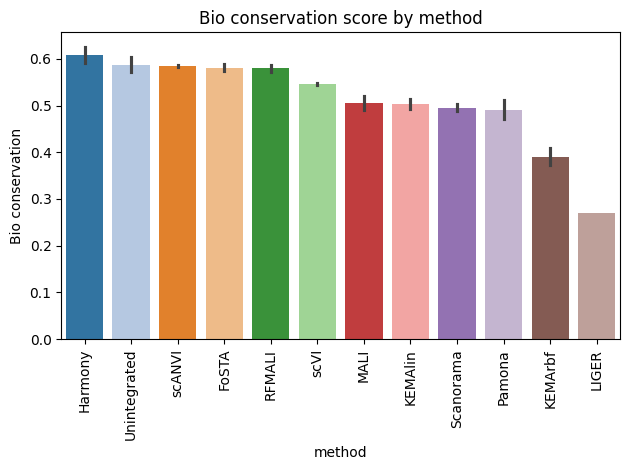

In [38]:
boxplot(results_df, col="Bio conservation", savedir = save_path)

# Bar plots

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


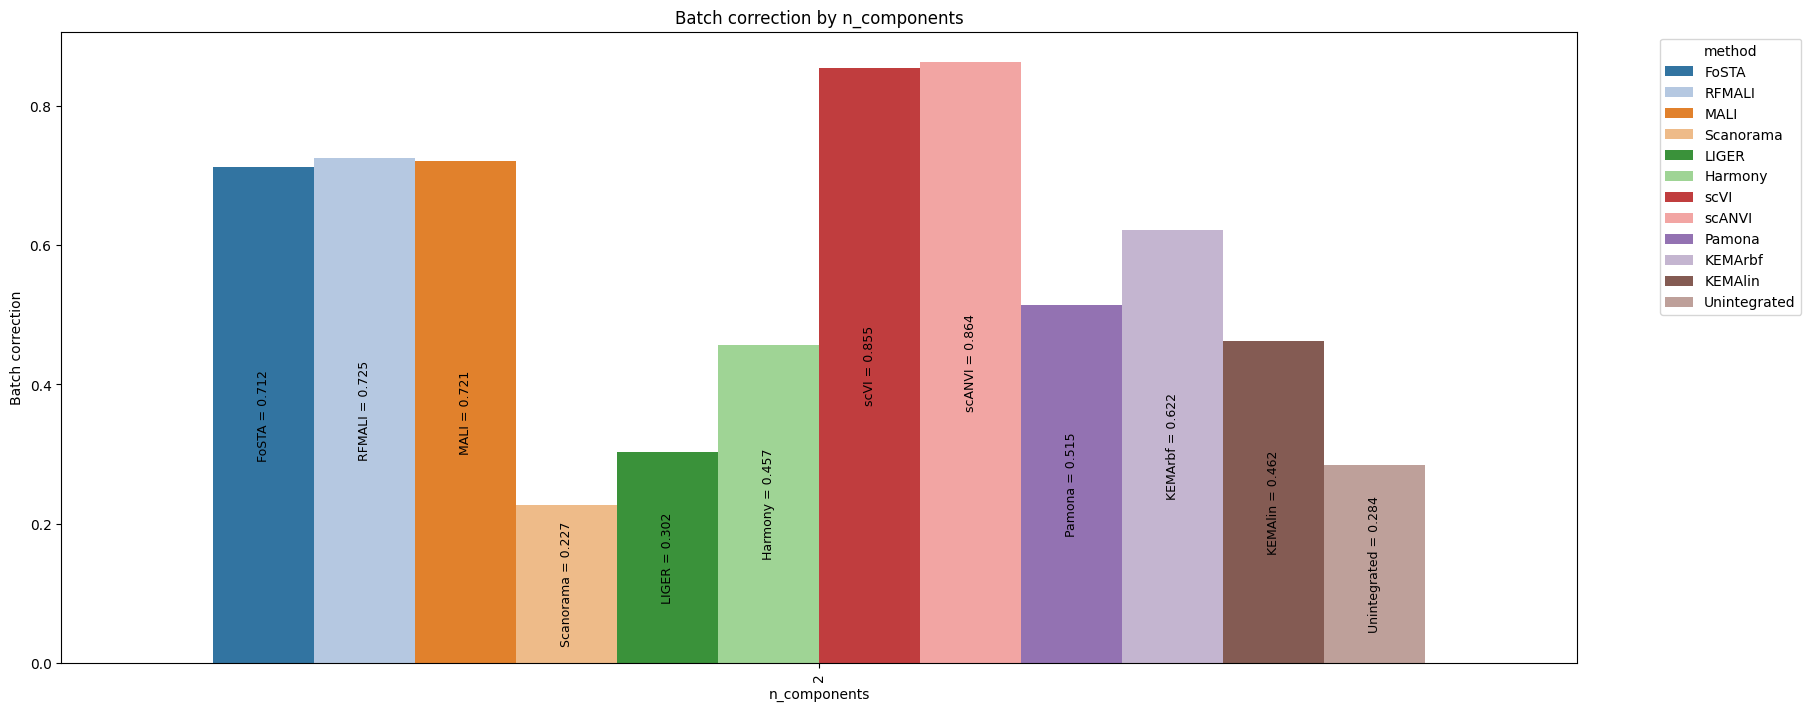

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


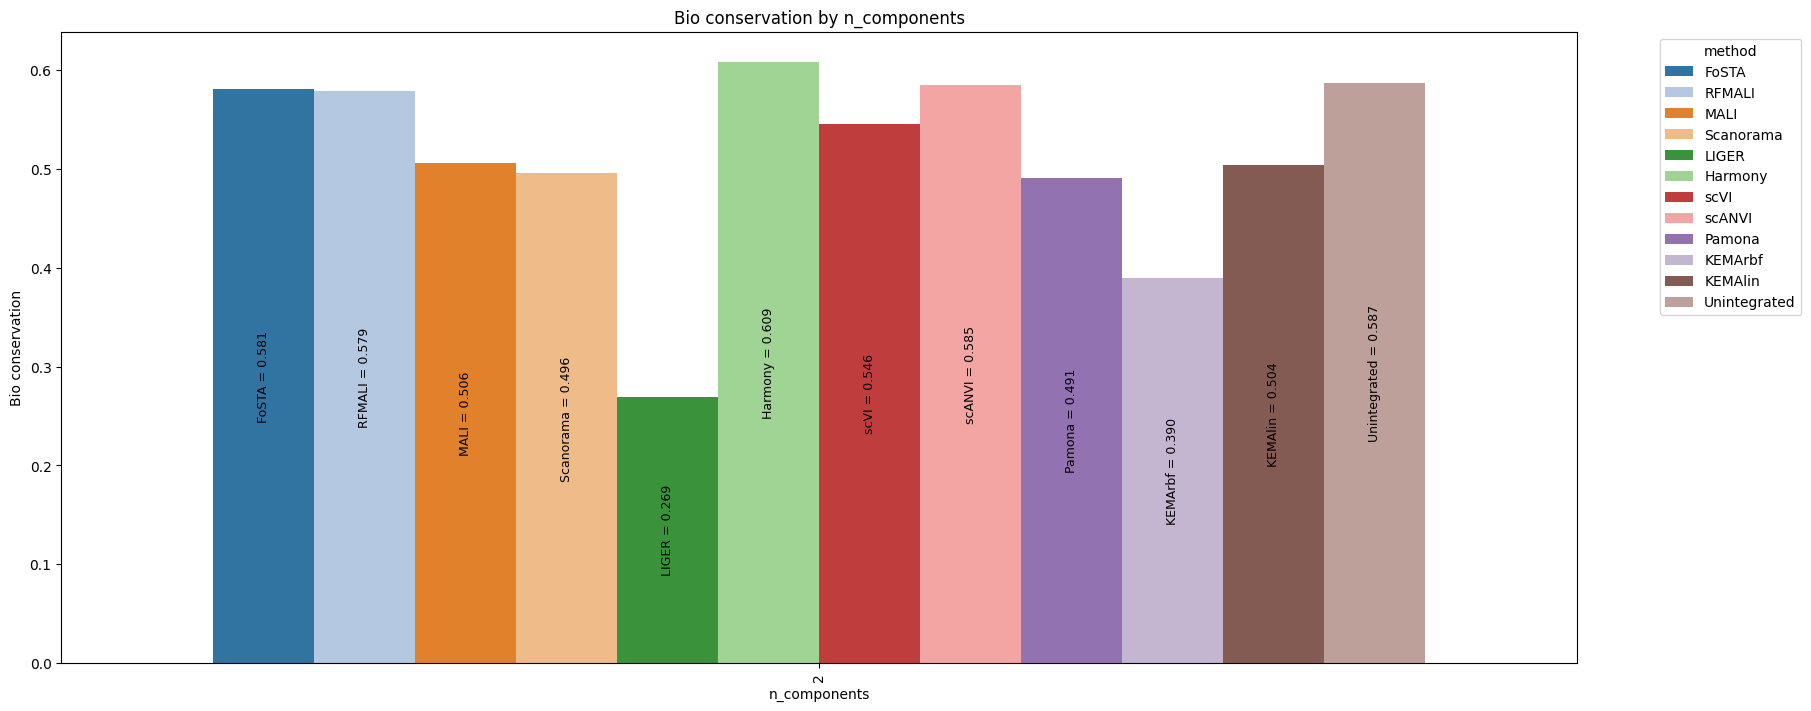

/home/mila/m/myriam.lizotte/RF-MALI/notebooks/../utils/plotting_utils.py:239: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


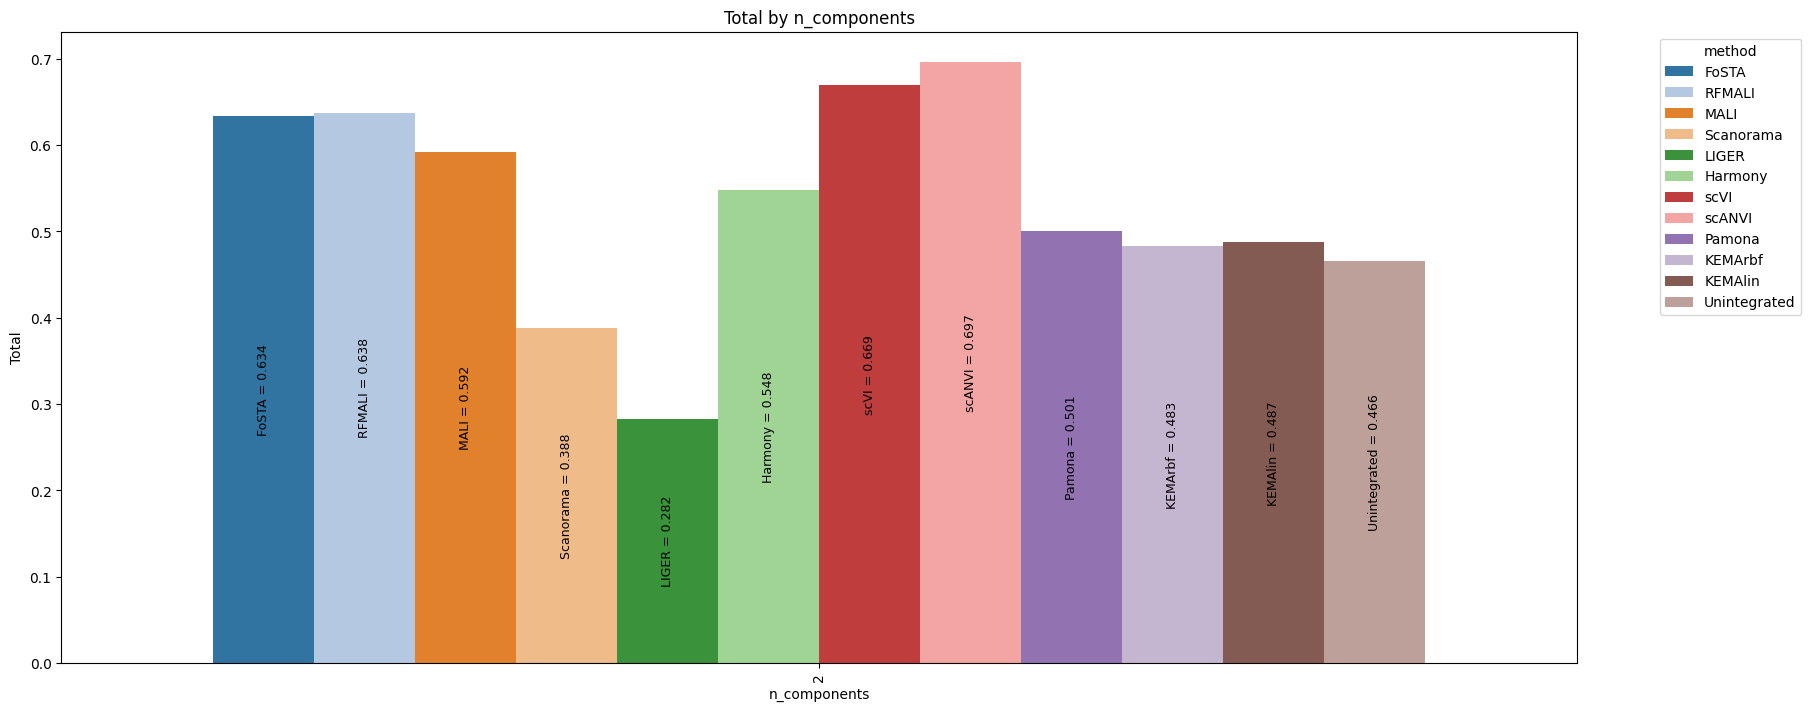

In [39]:
plot_metric_grouped_by(results_df, groupby_cols=["n_components", "method"])

subset to 2 components for visualization

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


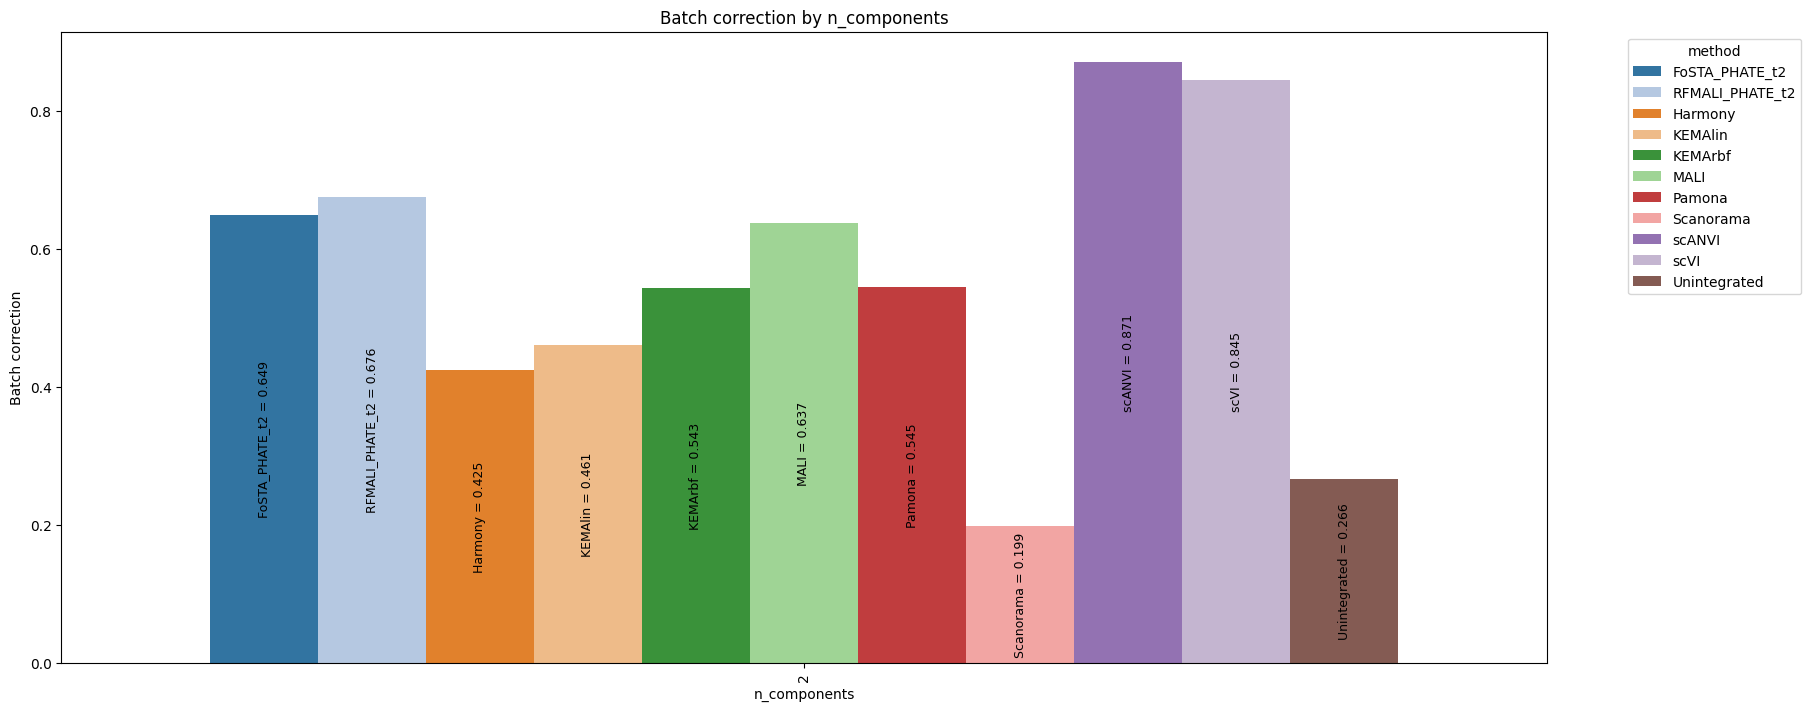

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


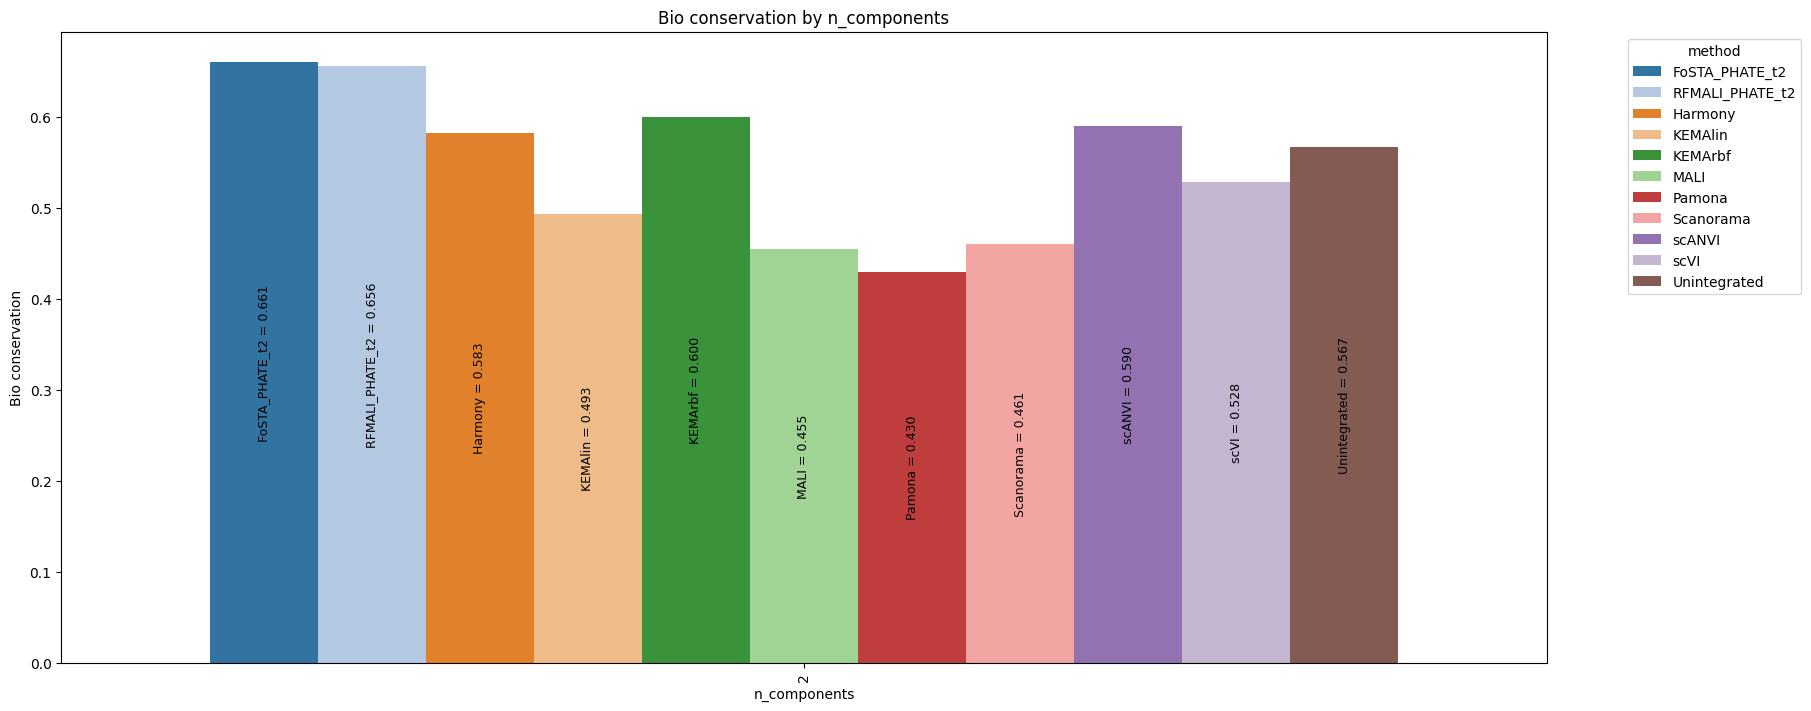

/tmp/ipykernel_3118097/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


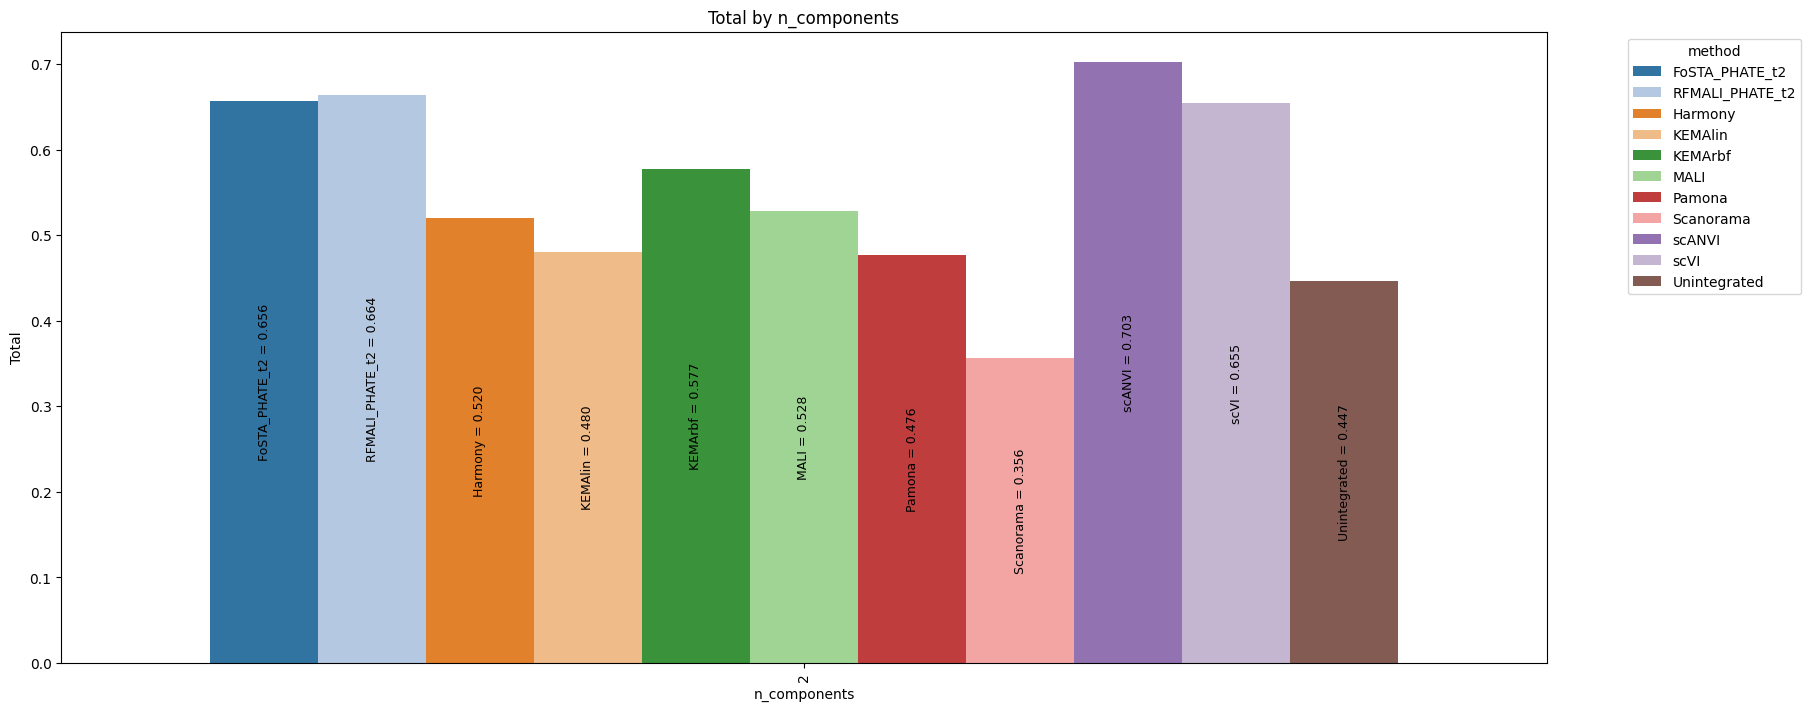

In [57]:
plot_metric_grouped_by(results_df, groupby_cols=["n_components","method"], n_components=2)

effect of noise when fixing dropout at 0.1:

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


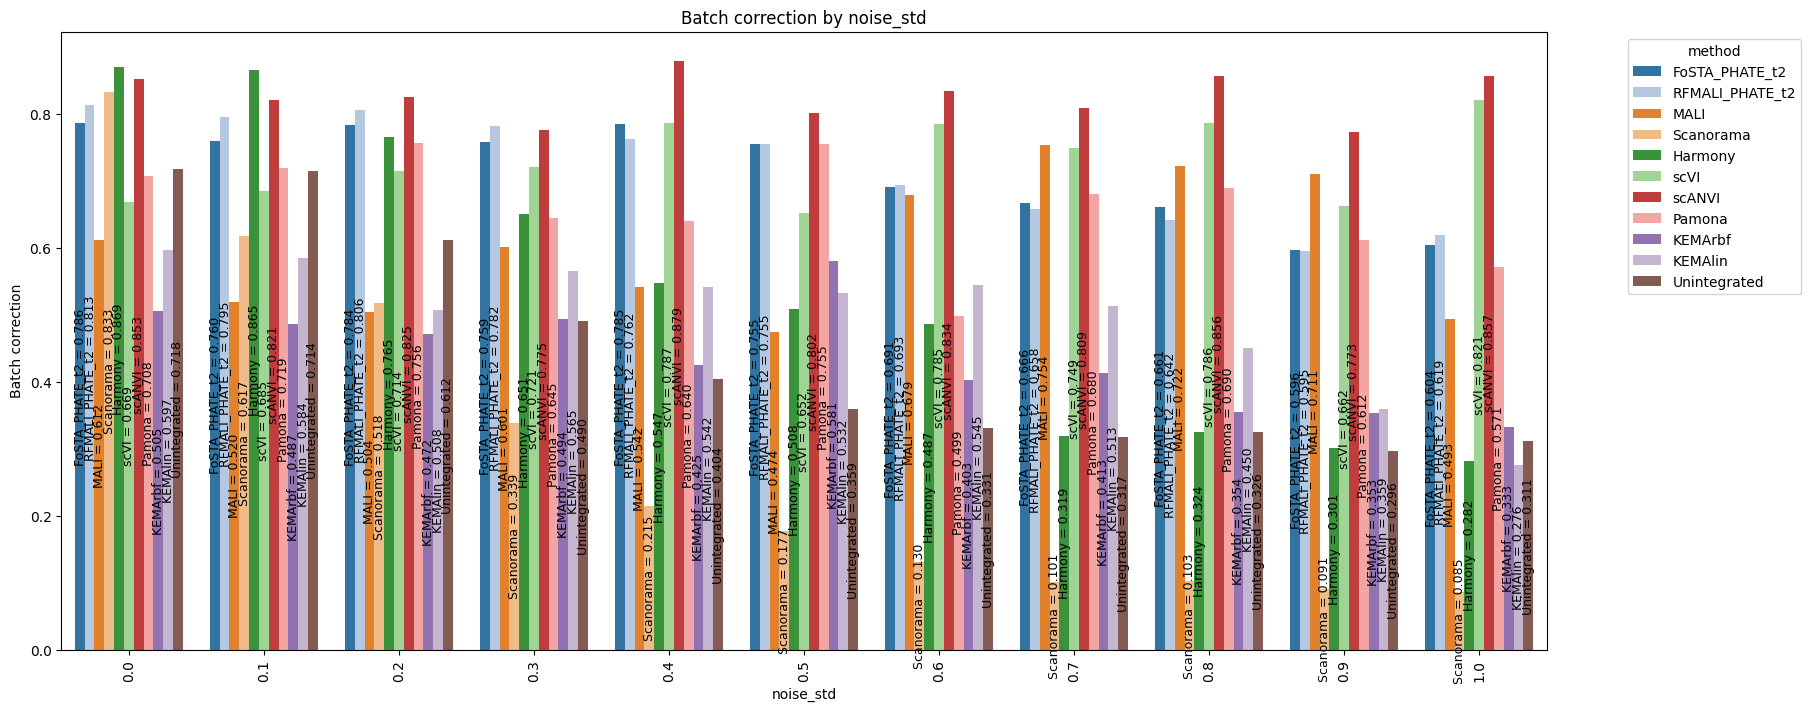

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


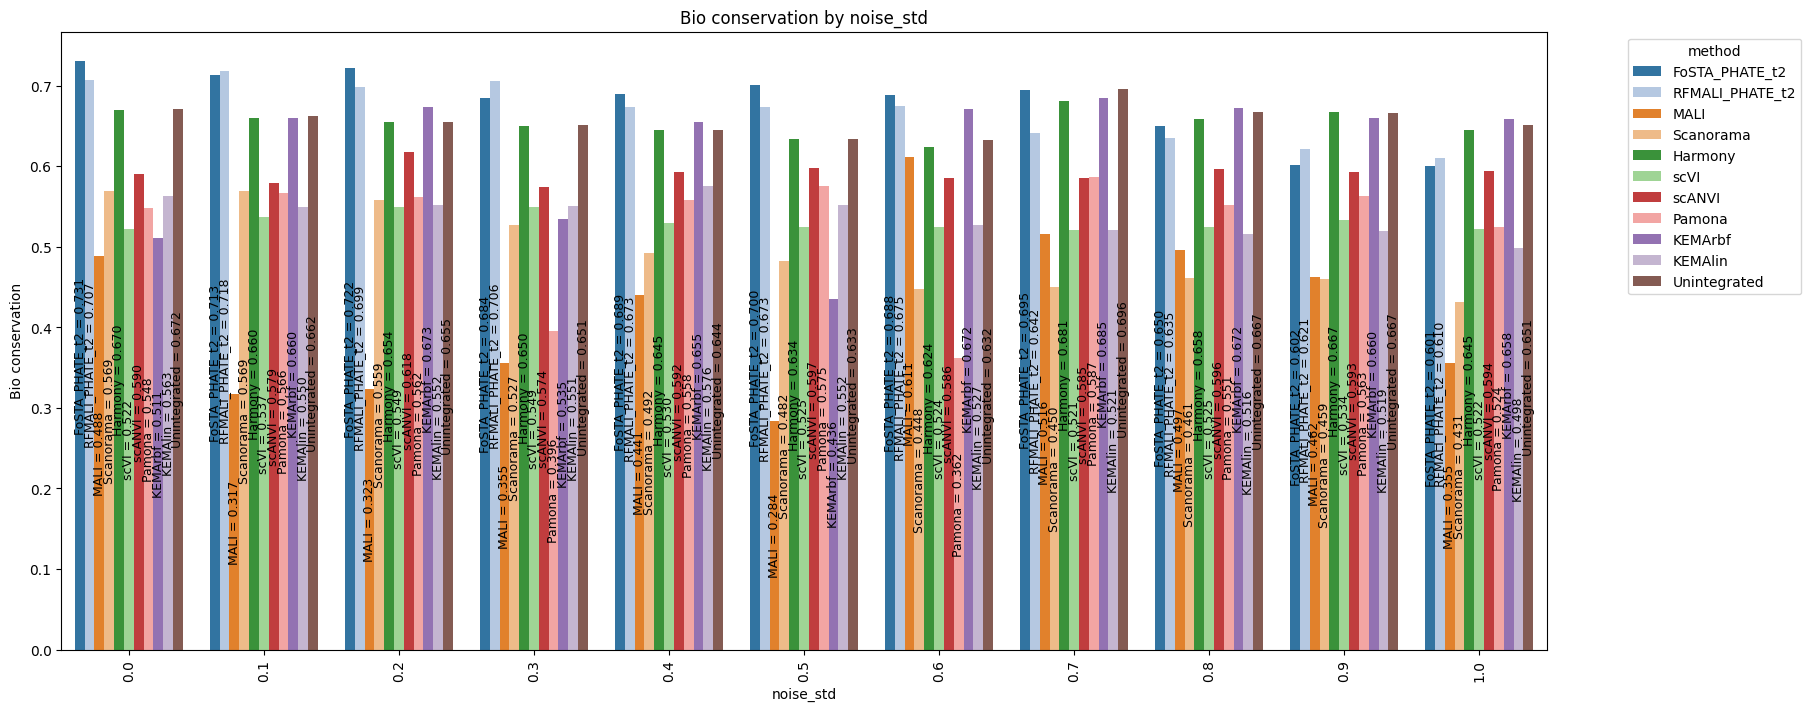

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


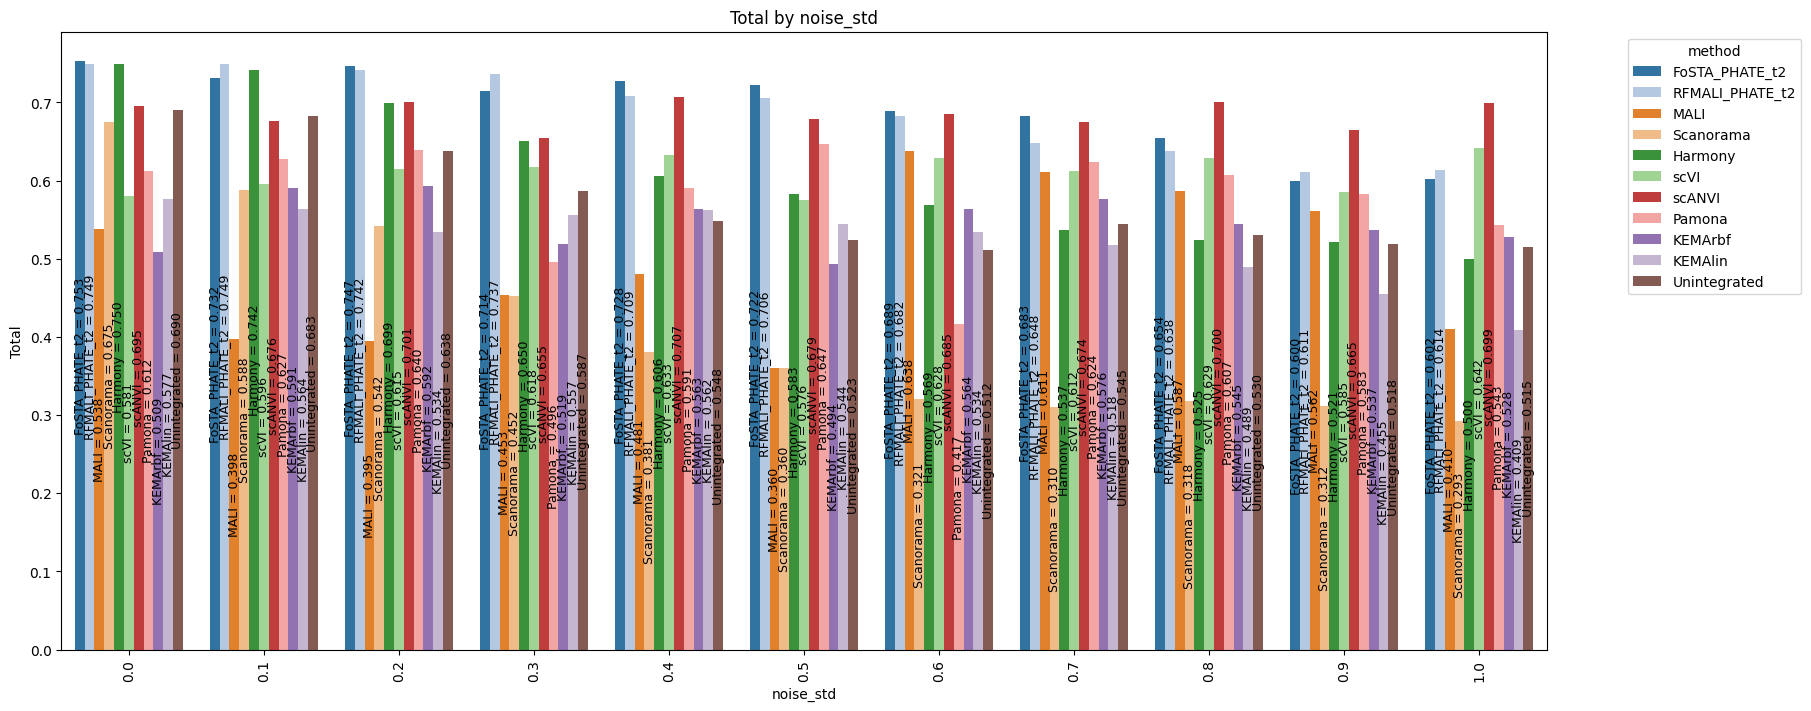

In [25]:
# pick one n_components and see effect of noise and dropout

n_comp = 2.0
dropout = 0.0

results_df_subset = results_df.loc[(results_df["n_components"] == n_comp) & (results_df["dropout_prob"] == dropout)]

plot_metric_grouped_by(results_df_subset, groupby_cols=["noise_std", "method"])


effect of dropout when fixing noise at 0

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


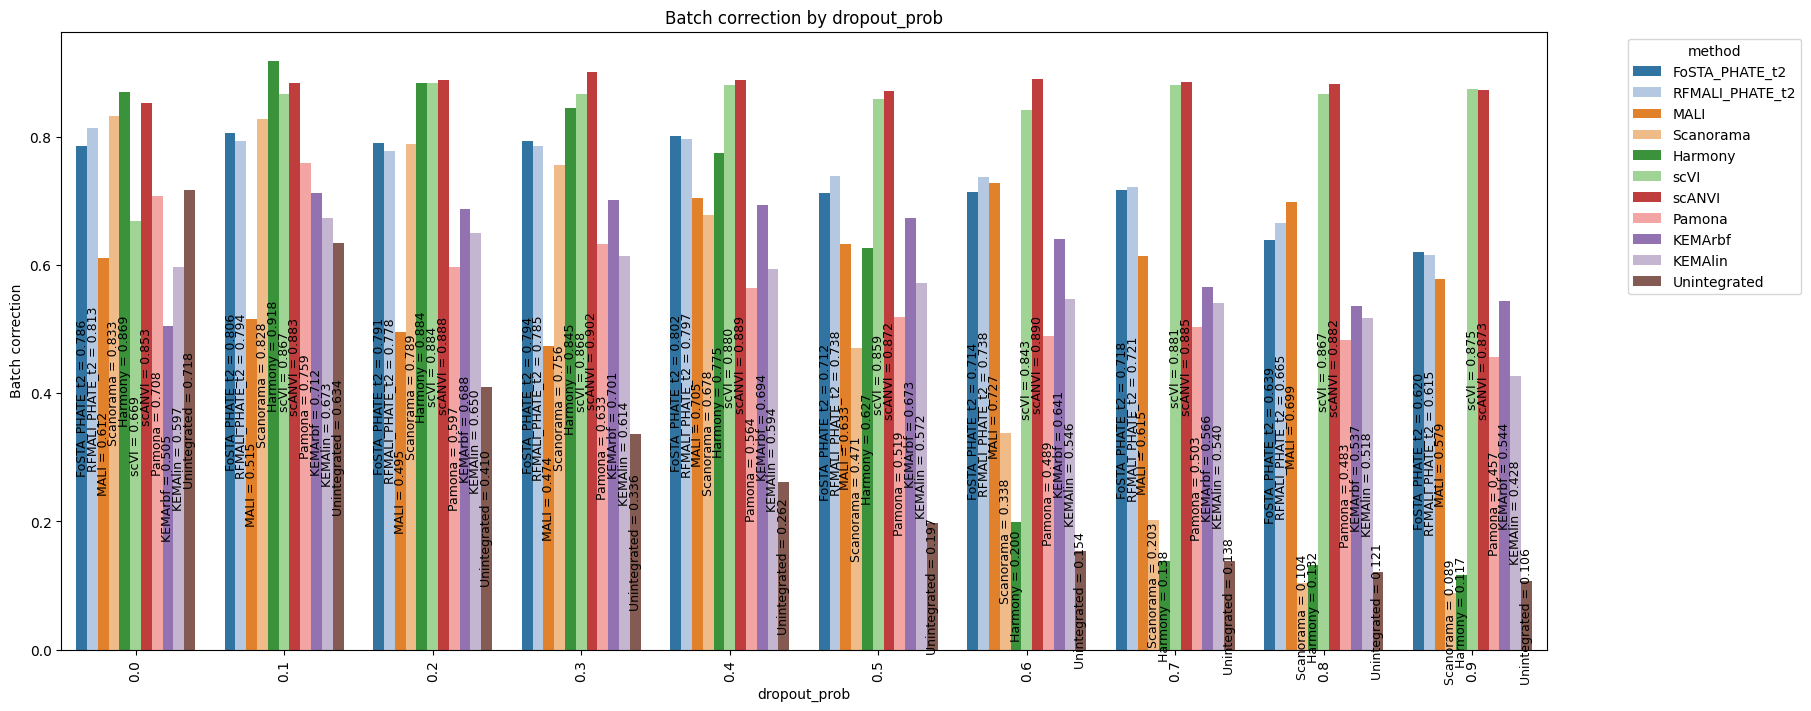

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


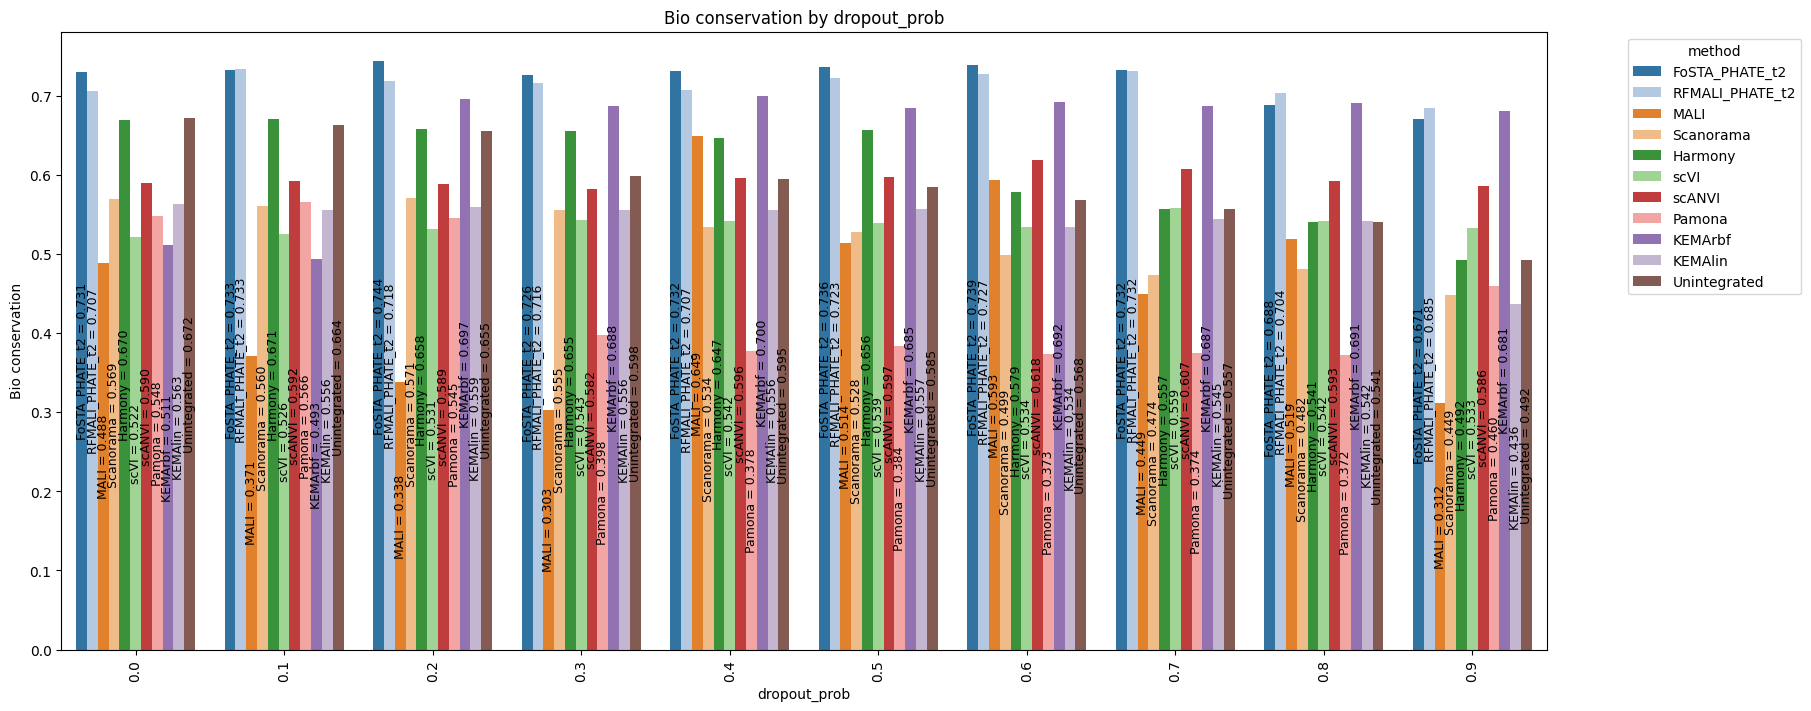

/tmp/ipykernel_3722924/981197081.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  results_df.groupby(groupby_cols, as_index=False)[col]


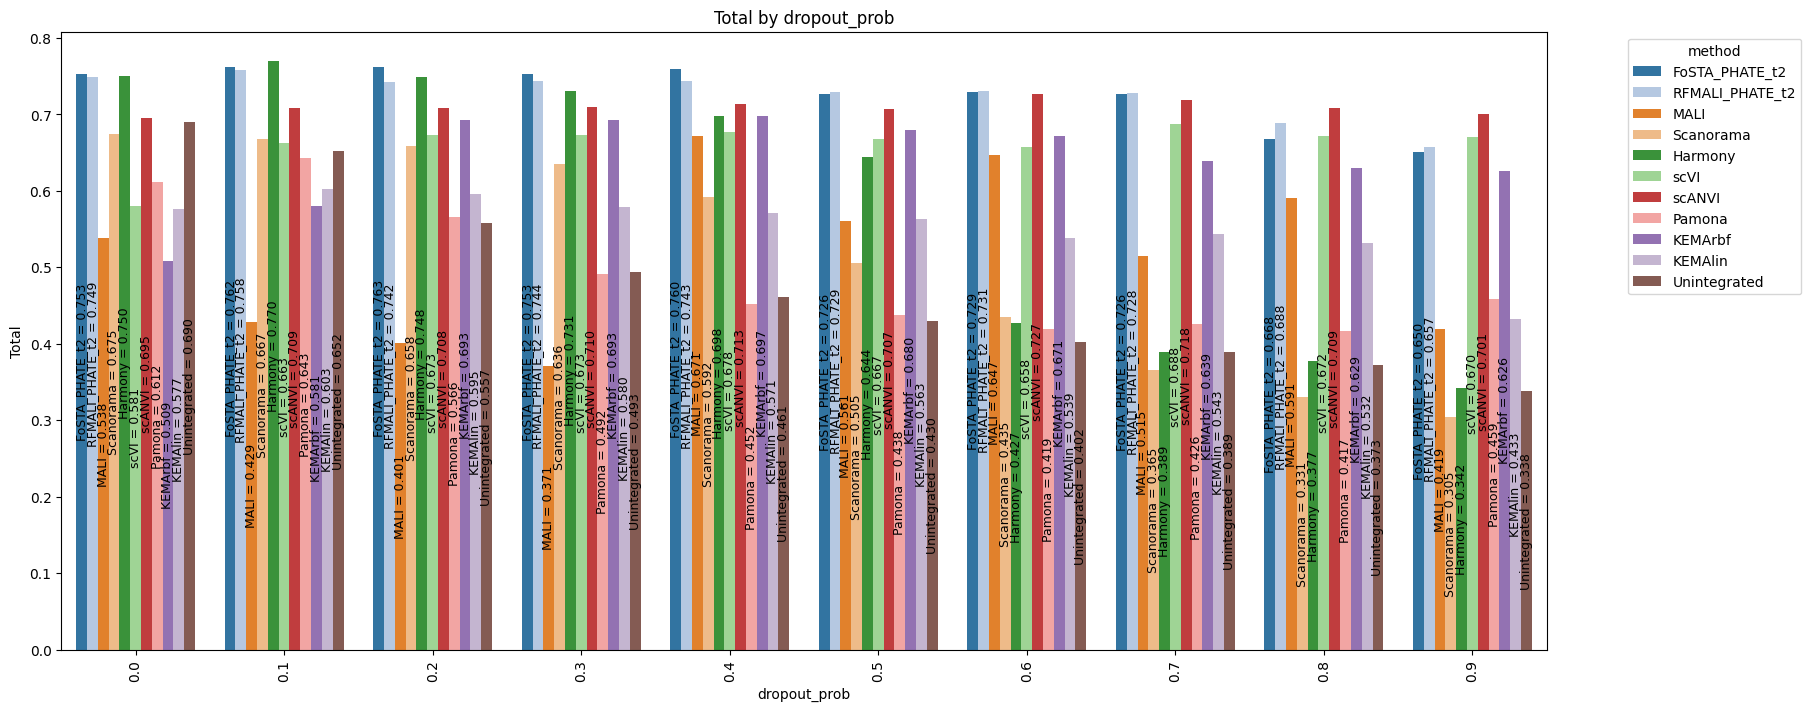

In [26]:
# pick one n_components and see effect of noise and dropout

n_comp = 2
noise = 0

results_df_subset = results_df.loc[(results_df["n_components"] == n_comp) & (results_df["noise_std"] == noise)]

plot_metric_grouped_by(results_df_subset, groupby_cols=["dropout_prob", "method"])

In [14]:
# # average over all components....
# cols_to_plot = ["Batch correction", "Bio conservation", "Total"]
# # 
# for col in cols_to_plot:
#    fig, ax = plt.subplots(figsize=(8, 6))
   
   
#    data = results_df.groupby(['n_components', 'method'])[col].mean()
#    print(data)
   
# #    data.plot(kind='bar', title=col)
#    for n_comp in results_df['n_components'].unique():
#       sns.barplot(data=data[n_comp])
   
   
#       # show the mean
#       for p in ax.patches:
#          h, w, x = p.get_height(), p.get_width(), p.get_x()
#          xy = (x + w / 2., h / 2)
#          text = f'{h:0.3f}'
#          ax.annotate(text=text, xy=xy, ha='center', va='top')
         
#       plt.title(f"{col} - n_components: {n_comp}")
#       plt.xticks(rotation=90)
#       plt.show()

for each method, heatmap of performance over different noise/dropout

In [85]:
# for method in results_df['method'].unique():
#     method_df = results_df[results_df['method'] == method]
#     # results_df["Total"] = pd.to_numeric(results_df["Total"], errors="coerce")
#     heatmap_df = method_df.pivot(index= "dropout_prob", columns= "noise_std", values = "Total")
    
#     # method_df = method_df.mean().to_frame(name='score')
    
#     plt.figure(figsize=(10,6))
#     sns.heatmap(data=heatmap_df, vmin=0, vmax=1, cmap= "viridis")
#     plt.title(f"Total Score for Method: {method}")
#     plt.ylabel("Dropout Probability")
#     plt.xlabel("Noise Standard Deviation")
    

# scatter plot of bio vs batch

/tmp/ipykernel_3722924/188192993.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratio_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()


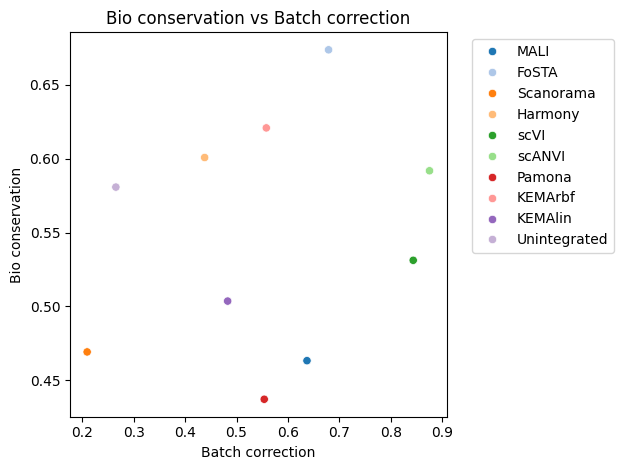

In [ ]:
n_components = 2
results_df_n_comp = results_df[results_df["n_components"] == n_components]

results_df_subset = results_df_n_comp
# # if i fix no noise, only dropout:
# results_df_subset = results_df_n_comp[results_df_n_comp["noise_std"] == 10]

# results_df_subset = results_df_n_comp[results_df_n_comp["noise_std"] == 1.0]
# if i fix no noise, only dropout:
# results_df_subset = results_df_n_comp[results_df_n_comp["dropout_prob"] == 0.8]





/tmp/ipykernel_3095895/3113557787.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()
/tmp/ipykernel_3095895/3113557787.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].std()


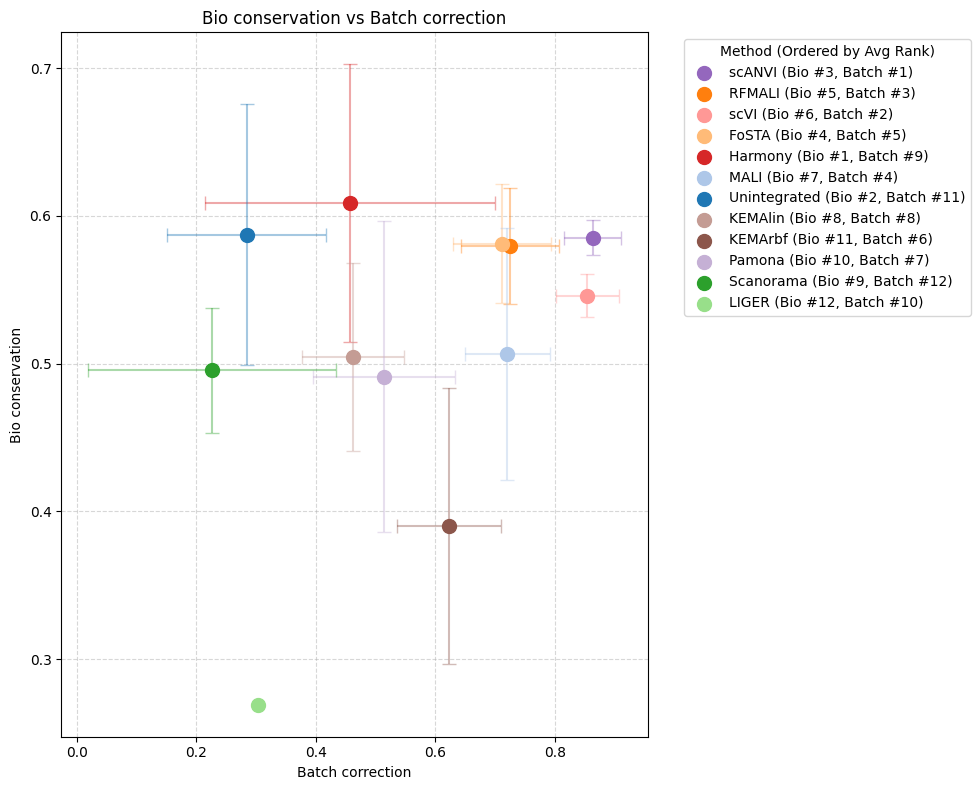

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Previous code for filtering results_df_subset) ...
n_components = 2
results_df_n_comp = results_df[results_df["n_components"] == n_components]
results_df_subset = results_df_n_comp

def plot_bio_vs_batch_correction(results_df, save_path=None):
    # 1. Calculate Mean and Standard Deviation
    mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()
    std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].std()
    std_df = std_df.fillna(0)

    # 2. Calculate Ranks (Assuming higher score is better -> ascending=False)
    mean_df['Bio Rank'] = mean_df['Bio conservation'].rank(ascending=False).astype(int)
    mean_df['Batch Rank'] = mean_df['Batch correction'].rank(ascending=False).astype(int)
    
    # 3. Calculate Average Rank and Sort
    mean_df['Avg Rank'] = (mean_df['Bio Rank'] + mean_df['Batch Rank']) / 2
    mean_df = mean_df.sort_values('Avg Rank')

    plt.figure(figsize=(10, 8)) 
    
    # Use a fixed color map so colors stay consistent regardless of sorting
    unique_methods = results_df['method'].unique()
    # Create palette
    palette_list = sns.color_palette("tab20", n_colors=len(unique_methods))
    color_map = dict(zip(unique_methods, palette_list))
    
    # Iterate through the SORTED methods
    for method in mean_df.index:
        x = mean_df.loc[method, "Batch correction"]
        y = mean_df.loc[method, "Bio conservation"]
        x_err = std_df.loc[method, "Batch correction"]
        y_err = std_df.loc[method, "Bio conservation"]
        
        bio_rank = mean_df.loc[method, 'Bio Rank']
        batch_rank = mean_df.loc[method, 'Batch Rank']
        avg_rank = mean_df.loc[method, 'Avg Rank']

        # Legend Label: Includes Bio and Batch ranks
        legend_label = f"{method} (Bio #{bio_rank}, Batch #{batch_rank})"

        # 4. Plot Error Bars
        plt.errorbar(
            x, y, 
            xerr=x_err, 
            yerr=y_err, 
            fmt='none',
            ecolor=color_map[method],
            elinewidth=1.5,
            capsize=5,
            alpha=0.4, 
            label=None 
        )

        # 5. Plot the Marker (No annotation on plot)
        plt.scatter(
            x, y, 
            s=100, 
            color=color_map[method], 
            label=legend_label, 
            zorder=3
        )

    # 6. Final Formatting
    plt.legend(
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        title="Method (Ordered by Avg Rank)",
        frameon=True
    )
    
    plt.title("Bio conservation vs Batch correction")
    plt.xlabel("Batch correction")
    plt.ylabel("Bio conservation")
    plt.grid(True, linestyle='--', alpha=0.5)

    if save_path is not None:
        plt.tight_layout()
        plt.savefig(f"{save_path}/bio_vs_batch_correction_ncomp_{n_components}.pdf", format='pdf')
        plt.savefig(f"{save_path}/bio_vs_batch_correction_ncomp_{n_components}.png", format='png')
    plt.show()

plot_bio_vs_batch_correction(results_df_subset, save_path=save_path)

/tmp/ipykernel_3722924/596952985.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()
/tmp/ipykernel_3722924/596952985.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].std()


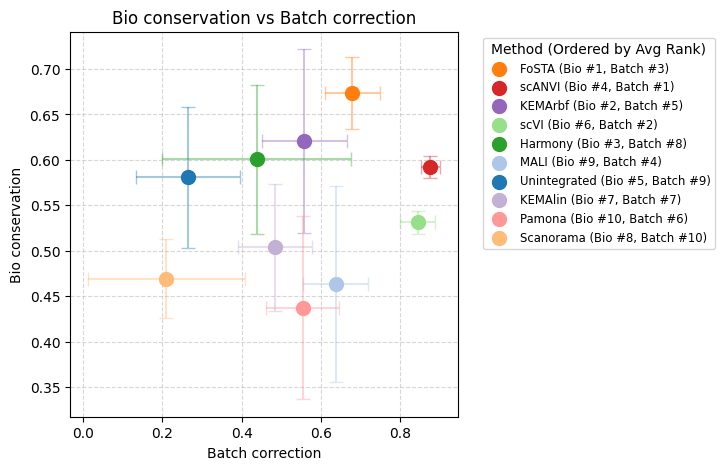

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# ... (Previous code for filtering results_df_subset) ...
n_components = 2
results_df_n_comp = results_df[results_df["n_components"] == n_components]
results_df_subset = results_df_n_comp

def plot_bio_vs_batch_correction(results_df, save_path=None):
    # 1. Calculate Mean and Standard Deviation
    mean_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].mean()
    std_df = results_df.groupby(['method'])[["Bio conservation", "Batch correction"]].std()
    std_df = std_df.fillna(0)

    # 2. Calculate Ranks
    mean_df['Bio Rank'] = mean_df['Bio conservation'].rank(ascending=False).astype(int)
    mean_df['Batch Rank'] = mean_df['Batch correction'].rank(ascending=False).astype(int)
    
    # 3. Calculate Average Rank and Sort
    mean_df['Avg Rank'] = (mean_df['Bio Rank'] + mean_df['Batch Rank']) / 2
    mean_df = mean_df.sort_values('Avg Rank')

    # --- ADJUSTMENT: Smaller Figure Size ---
    plt.figure(figsize=(5, 5)) 
    
    unique_methods = results_df['method'].unique()
    palette_list = sns.color_palette("tab20", n_colors=len(unique_methods))
    color_map = dict(zip(unique_methods, palette_list))
    
    for method in mean_df.index:
        x = mean_df.loc[method, "Batch correction"]
        y = mean_df.loc[method, "Bio conservation"]
        x_err = std_df.loc[method, "Batch correction"]
        y_err = std_df.loc[method, "Bio conservation"]
        
        bio_rank = mean_df.loc[method, 'Bio Rank']
        batch_rank = mean_df.loc[method, 'Batch Rank']
        legend_label = f"{method} (Bio #{bio_rank}, Batch #{batch_rank})"

        # Plot Error Bars
        plt.errorbar(
            x, y, 
            xerr=x_err, 
            yerr=y_err, 
            fmt='none',
            ecolor=color_map[method],
            elinewidth=1.5,
            capsize=5,
            alpha=0.4, 
            label=None 
        )

        # Plot Marker
        plt.scatter(
            x, y, 
            s=100, 
            color=color_map[method], 
            label=legend_label, 
            zorder=3
        )

    # --- ADJUSTMENT: Legend Styling ---
    plt.legend(
        bbox_to_anchor=(1.05, 1), 
        loc='upper left', 
        title="Method (Ordered by Avg Rank)",
        frameon=True,
        fontsize='small',  # Make text smaller to fit the smaller figure height
        title_fontsize='medium'
    )
    
    plt.title("Bio conservation vs Batch correction")
    plt.xlabel("Batch correction")
    plt.ylabel("Bio conservation")
    plt.grid(True, linestyle='--', alpha=0.5)

    if save_path is not None:
        # 'bbox_inches="tight"' ensures the external legend is not cut off when saving
        plt.savefig(f"{save_path}/bio_vs_batch_correction_ncomp_{n_components}.pdf", format='pdf', bbox_inches="tight")
        plt.savefig(f"{save_path}/bio_vs_batch_correction_ncomp_{n_components}.png", format='png', bbox_inches="tight")
    plt.show()

plot_bio_vs_batch_correction(results_df_subset, save_path=save_path)

all points for all methods

/tmp/ipykernel_3722924/1864013628.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data = results_df_n_comp.groupby(['noise_std', 'dropout_prob', 'method'])[["Bio conservation", "Batch correction"]].mean()


<Axes: xlabel='Batch correction', ylabel='Bio conservation'>

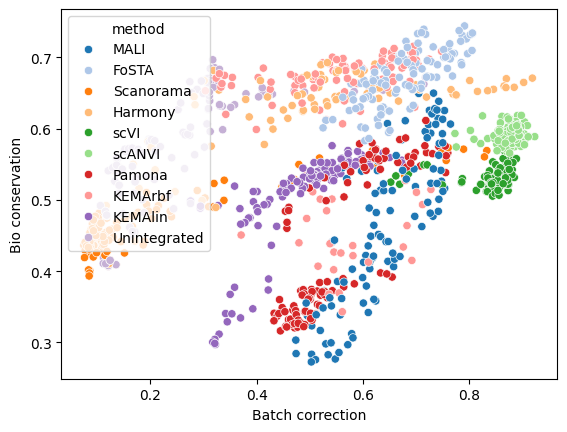

In [56]:
data = results_df_n_comp.groupby(['noise_std', 'dropout_prob', 'method'])[["Bio conservation", "Batch correction"]].mean()
    
sns.scatterplot(data=data, x="Batch correction", y="Bio conservation", hue = "method", palette="tab20")

In [65]:
# for method in results_df["method"].unique():
#     method_df = results_df[results_df["method"] == method]
#     data = method_df.groupby(['noise_std', 'dropout_prob'])[["Bio conservation", "Batch correction"]].mean()
    
#     sns.scatterplot(data=data, x="Batch correction", y="Bio conservation")
#     plt.title(f"Method: {method}")
#     plt.show()

# clean up cell types

/tmp/ipykernel_3722924/992292415.py:11: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {small_type: "Other"}}, inplace=True)


# visualize embeddings

In [14]:
import scanpy as sc
import matplotlib.pyplot as plt


def load_adata(save_path, fosta_key = "FoSTA_PHATE_t2", noise_level=0.5, dropout_level=0.5, seed = 39041):
    # format noise and dropout to match folder names (1 decimal place)
    noise_level = f"{noise_level:.1f}"
    dropout_level = f"{dropout_level:.1f}"
    path = f"{save_path}/noise_{noise_level}_dropout_{dropout_level}/2_components/seed_{seed}"
    adata = sc.read_h5ad(f"{path}/adata_intermediate.h5ad")
    # rename FoSTA_PHATE_t2 to FoSTA in the adata
    adata.obsm["FoSTA"] = adata.obsm[fosta_key]
    del adata.obsm[fosta_key]
    
    return adata, path


def plot_embeddings(adata = None, methods = None, noise_level=0.5, dropout_level=0.5, seed=39041, save_path = None, rename_dict = None, figsize=None, **kwargs):
    label_key = "cell_type"
    batch_key = "simulated_batch"
    

    if adata is None:
        adata, save_path = load_adata(save_path=save_path, noise_level=noise_level, dropout_level=dropout_level, seed=seed)
     
    if methods is None:
        methods = list(adata.obsm.keys())
    n = len(methods)
    
    if figsize is None:
        figsize = (6*n, 8)
        
    fig, axes = plt.subplots(figsize=figsize, nrows=2, ncols=n)


    # ---- TOP ROW (batch_key) ----
    for i, method in enumerate(methods):
        if rename_dict is None:
            method_name = method
        else:
            method_name = rename_dict[method]
            
        sc.pl.embedding(
            adata,
            ax=axes[0, i],
            basis=method,
            color=batch_key,
            title=f"{method_name}", # : {batch_key}
            show=False,
            legend_loc="right" if i == 0 else None,  # create legend ONCE
            **kwargs
        )

    # ---- BOTTOM ROW (label_key) ----
    for i, method in enumerate(methods):
        if rename_dict is None:
            method_name = method
        else:
            method_name = rename_dict[method]
            
        sc.pl.embedding(
            adata,
            ax=axes[1, i],
            basis=method,
            color=label_key,
            title=f"{method_name}", # {label_key}
            show=False,
            legend_loc="right" if i == 0 else None,
            **kwargs
        )

    # ---- EXTRACT + MOVE LEGENDS ----
    leg_top = axes[0, 0].get_legend()
    leg_bottom = axes[1, 0].get_legend()

    # remove them from axes
    axes[0, 0].legend_.remove()
    axes[1, 0].legend_.remove()

    # IMPORTANT: anchor legends in FIGURE coordinates
    plt.tight_layout(rect=[0, 0, 0.88, 1])
    leg_top.set_bbox_to_anchor((0.88, 0.75), transform=fig.transFigure)
    leg_bottom.set_bbox_to_anchor((0.88, 0.25), transform=fig.transFigure)
    leg_top.set_loc("center left")
    leg_bottom.set_loc("center left")

    # add them back to the figure
    fig.add_artist(leg_top)
    fig.add_artist(leg_bottom)

    # plt.show()

    # plt.title(f"Noise level: {noise_level}, Dropout level: {dropout_level}")
    if save_path is not None:
        plt.savefig(f"{save_path}/all_methods_embeddings.png", bbox_inches='tight', format="png")
        plt.savefig(f"{save_path}/all_methods_embeddings.pdf", bbox_inches='tight', format="pdf")

In [164]:
# plot_embeddings(methods = ["Unintegrated", "FoSTA_PHATE_t2", "scANVI"], noise_level=0.5, dropout_level=0.5)

In [18]:
import phate
import rfphate

# def plot_batches(methods = None, noise_level=0.5, dropout_level=0.5):
def add_rfphate_phate_embeddings(save_path, fosta_key = "FoSTA_PHATE_t2", adata = None, label_key = "cell_type", batch_key = "simulated_batch", noise_level=0.5, dropout_level=0.5, embedding_basis = "X_pca", t=2):
    if adata is None:
        adata, path = load_adata(save_path, fosta_key=fosta_key, noise_level=noise_level, dropout_level=dropout_level)
    else:
        path = None
    phate_operator = phate.PHATE(n_components=2, t=t)
    rfphate_operator = rfphate.RFPHATE(n_components=2, t=t)

    phate_embeddings = phate_operator.fit_transform(adata.obsm[embedding_basis])
    rfphate_embeddings = rfphate_operator.fit_transform(adata.obsm[embedding_basis], adata.obs[label_key])

    adata.obsm[f"PHATE_t{t}"] = phate_embeddings
    adata.obsm[f"RFPHATE_t{t}"] = rfphate_embeddings
    
    return adata, path

    SGD-MDS may not have converged: stress changed by -7.8% in final iterations. Consider increasing n_iter or adjusting learning_rate.
    SGD-MDS may not have converged: stress changed by -3.2% in final iterations. Consider increasing n_iter or adjusting learning_rate.


KeyError: "Could not find 'RFPHATE_2' or 'X_RFPHATE_2' in .obsm"

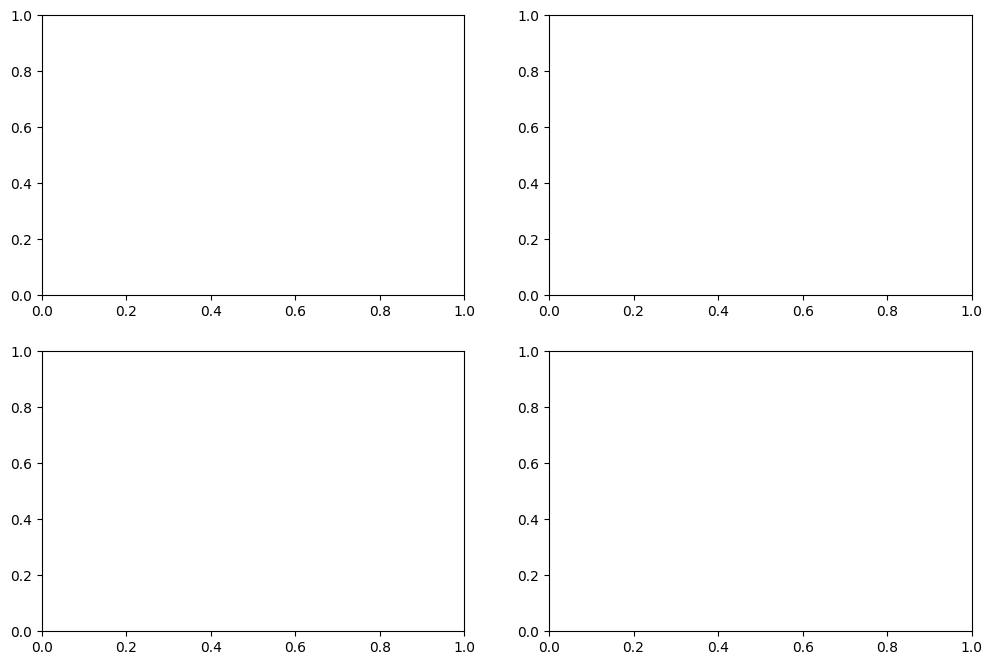

In [236]:
ts = [2, 4, 8, 12]
# ks = [5, 10, 20]
k=0
# for k in ks:
for t in ts:
    adata_no_noise, path = add_rfphate_phate_embeddings(adata=None, noise_level=0.0, dropout_level=0.0, t=t, knn =k)
    adata_t, path = add_rfphate_phate_embeddings(adata=None, noise_level=0.5, dropout_level=0.5, t=t, knn=k)
    
    # adatae = adata_t.obsm[f"PHATE_{t}_{k}"]
    # emb_rfphate = adata_t.obsm[f"RFPHATE_{t}_{k}"]
    # adata_t.obsm[f"PHATE_no_noise_{t}_{k}"] = adata_no_noise.obsm[f"PHATE_{t}_{k}"]
    adata_t.obsm[f"RFPHATE_no_noise_{t}_{k}"] = adata_no_noise.obsm[f"RFPHATE_{t}_{k}"]
    # plot_embeddings(adata_t, methods = [f"PHATE_{t}_{k}", f"RFPHATE_{t}_{k}",  f"RFPHATE_no_noise_{t}_{k}" , f"PHATE_no_noise_{t}_{k}"])
    # plot_embeddings(adata_t, methods = [f"PHATE_{t}_{k}", f"PHATE_no_noise_{t}_{k}"])
    plot_embeddings(adata_t, methods = [f"RFPHATE_{t}", f"RFPHATE_no_noise_{t}"])
    plt.show()

good plot

In [19]:
save_path = "/NOBACKUP/lizottem/fosta/results/simulated_batches/2026-05-04_17-31-59/4"

# adata_no_noise, path = add_rfphate_phate_embeddings(save_path, adata=None, noise_level=0.0, dropout_level=0.0, t=2)
adata, path = add_rfphate_phate_embeddings(save_path, fosta_key = "ICML FoSTA t=2", adata=None, noise_level=0.5, dropout_level=0.5, t=2)

# adata.obsm["PHATE_no_noise_t2"] = adata_no_noise.obsm["PHATE_t2"]
# adata.obsm["RFPHATE_no_noise_t2"] = adata_no_noise.obsm["RFPHATE_t2"]

Calculating PHATE...
  Running PHATE on 3763 observations and 30 variables.
  Calculating graph and diffusion operator...
    Calculating KNN search...
    Calculated KNN search in 0.11 seconds.
    Calculating affinities...
    Calculated affinities in 1.72 seconds.
  Calculated graph and diffusion operator in 1.83 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 3.45 seconds.
    Calculating KMeans...
    Calculated KMeans in 2.36 seconds.
  Calculated landmark operator in 5.82 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.05 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 2.92 seconds.
Calculated PHATE in 11.12 seconds.


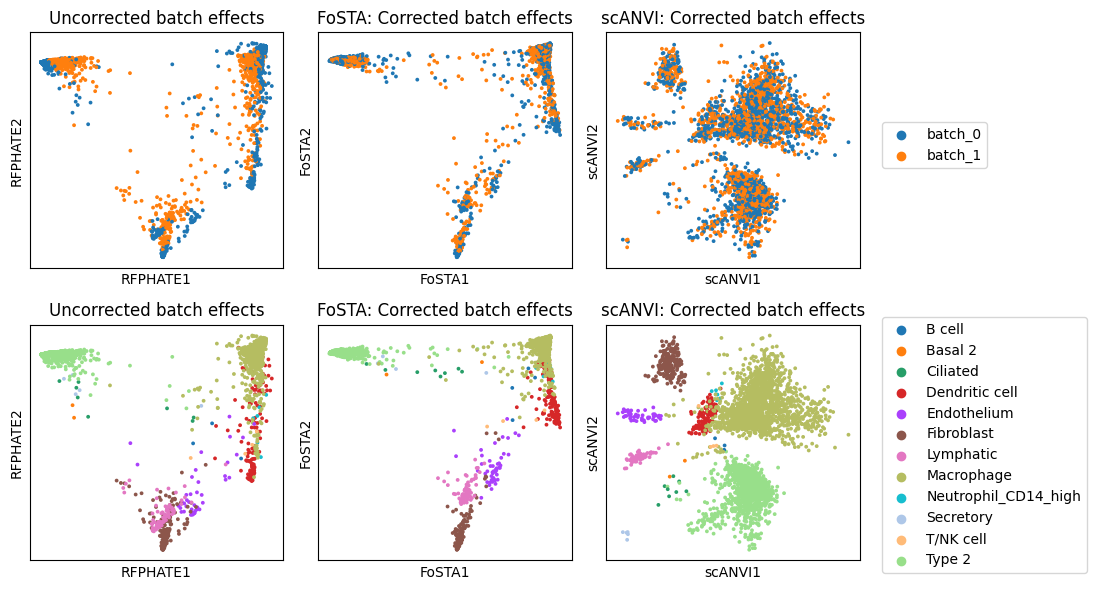

In [25]:
# rename RFPHATE_t2 to RFPHATE
adata.obsm["RFPHATE"] = adata.obsm["RFPHATE_t2"]
# del adata.obsm["RFPHATE_t2"]


renames = {"PHATE_no_noise_t2": "PHATE: Before batch effects",
           "RFPHATE_no_noise_t2": "Before batch effects",
            "PHATE_t2": "Uncorrected batch effects",
            "RFPHATE" : "Uncorrected batch effects",
            "FoSTA": "FoSTA: Corrected batch effects",
            "scANVI": "scANVI: Corrected batch effects"}

# methods = ["PHATE_no_noise_t2", 
# methods = ["RFPHATE_no_noise_t2", 
        #    "PHATE_t2", 
methods = ["RFPHATE", 
           "FoSTA",
           "scANVI"]

plot_embeddings(adata, methods = methods, save_path = path, rename_dict=renames, figsize=(10,6), s=30)

In [275]:
adata.obs["cell_type"].cat.categories

Index(['Other', 'Dendritic cell', 'Endothelium', 'Fibroblast', 'Lymphatic',
       'Macrophage', 'Alveolar Type 2'],
      dtype='object')

In [248]:
adata.write_h5ad(f"{path}/adata_with_phate_rfphate.h5ad")

# clean up cell types

In [26]:
adata.obs["original_cell_type"] = adata.obs["cell_type"]

threshold = 10

value_counts = adata.obs["cell_type"].value_counts()
small_types = value_counts.index[value_counts < threshold]

# replace cell_type "Type 2" with "Alveolar Type 2" 
adata.obs.replace({"cell_type": {"Type 2": "Alveolar Type 2"}}, inplace=True)


for small_type in small_types:
    adata.obs.replace({"cell_type": {small_type: "Other"}}, inplace=True)



/tmp/ipykernel_1842734/1520995164.py:9: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {"Type 2": "Alveolar Type 2"}}, inplace=True)
/tmp/ipykernel_1842734/1520995164.py:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  adata.obs.replace({"cell_type": {small_type: "Other"}}, inplace=True)


In [27]:


# reorder the categories so that "Other" is last
categories = [cat for cat in adata.obs["cell_type"].cat.categories if cat != "Other"]
categories.append("Other")
adata.obs["cell_type"] = adata.obs["cell_type"].cat.reorder_categories(categories)

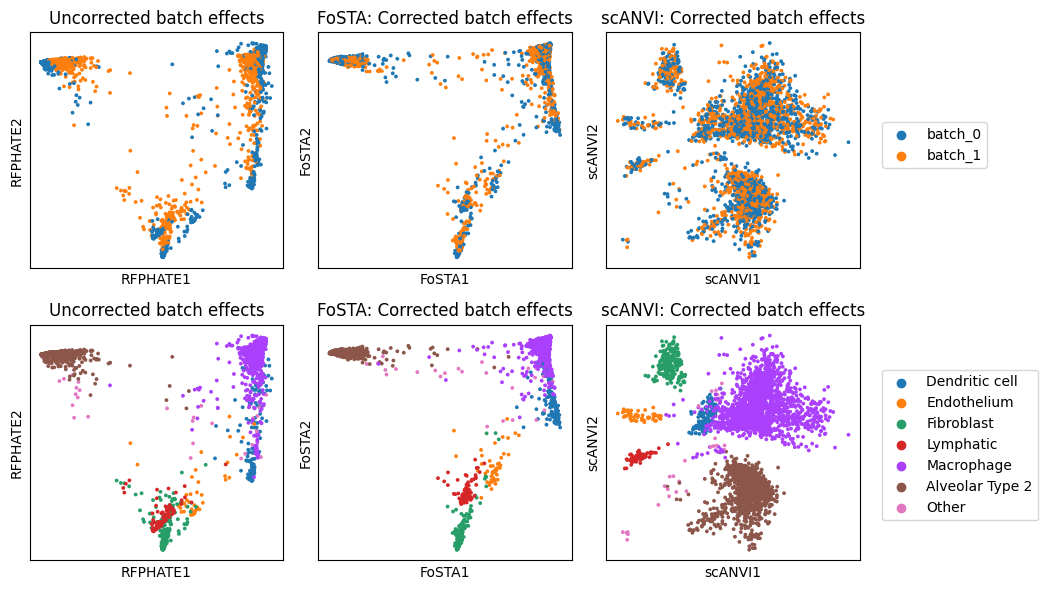

In [29]:
# rerun the plot

plot_embeddings(adata, methods = methods, save_path = path, rename_dict=renames, figsize=(10,6), s=30)